In [ ]:
# Install PyTorch Geometric for GCN
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 43.1 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import networkx as nx

from tensorflow.keras import layers, Model
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_networkx

# PART 1 : VARIATIONAL AUTOENCODER (VAE)

In [ ]:
# Load MNIST handwritten digit dataset
(x_train, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
# Add channel dimension
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [ ]:
# Size of latent vector
latent_dim = 2

In [ ]:
# Sampling layer for VAE
class Sampling(layers.Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(shape=tf.shape(z_mean))

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


In [ ]:
# ---------------- Encoder ----------------
# Encoder converts image into latent vector

encoder_input = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(
    32,
    3,
    activation="relu",
    strides=2,
    padding="same"
)(encoder_input)

x = layers.Conv2D(
    64,
    3,
    activation="relu",
    strides=2,
    padding="same"
)(x)

x = layers.Flatten()(x)

x = layers.Dense(128, activation="relu")(x)

In [ ]:
# Mean and variance vectors
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

In [ ]:
# Sample latent vector
z = Sampling()([z_mean, z_log_var])

In [ ]:
# Build encoder model
encoder = Model(
    encoder_input,
    [z_mean, z_log_var, z],
    name="encoder"
)

In [ ]:
# ---------------- Decoder ----------------
# Decoder reconstructs image from latent vector

decoder_input = layers.Input(shape=(latent_dim,))

x = layers.Dense(7 * 7 * 64, activation="relu")(decoder_input)

x = layers.Reshape((7, 7, 64))(x)

x = layers.Conv2DTranspose(
    64,
    3,
    strides=2,
    activation="relu",
    padding="same"
)(x)

x = layers.Conv2DTranspose(
    32,
    3,
    strides=2,
    activation="relu",
    padding="same"
)(x)

decoder_output = layers.Conv2DTranspose(
    1,
    3,
    activation="sigmoid",
    padding="same"
)(x)

In [ ]:
# Build decoder model
decoder = Model(
    decoder_input,
    decoder_output,
    name="decoder"
)

In [ ]:
# ---------------- VAE Model ----------------
# Custom training step for VAE

class VAE(Model):

    def __init__(self, encoder, decoder):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            # Encode images
            z_mean, z_log_var, z = self.encoder(data)

            # Reconstruct images
            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total loss
            total_loss = reconstruction_loss + kl_loss

        # Compute gradients
        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        # Update weights
        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_weights)
        )

        return {
            "loss": total_loss
        }


In [ ]:
# Create and compile VAE model
vae = VAE(encoder, decoder)

vae.compile(optimizer="adam")

In [ ]:
# Train VAE
vae.fit(
    x_train,
    epochs=8,
    batch_size=128
)

Epoch 1/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0000e+00
Epoch 2/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0000e+00
Epoch 3/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0000e+00
Epoch 4/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0000e+00
Epoch 5/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0000e+00
Epoch 6/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0000e+00
Epoch 7/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0000e+00
Epoch 8/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0000e+00


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


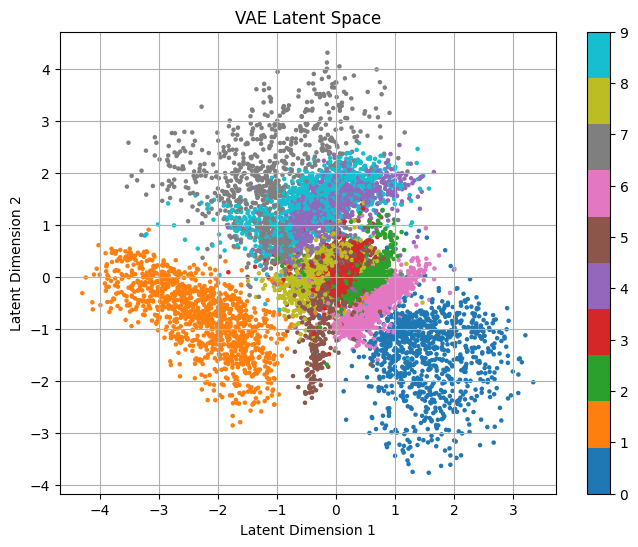

In [ ]:
# Visualize latent space
z_mean_values, _, _ = encoder.predict(x_test)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    z_mean_values[:, 0],
    z_mean_values[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.colorbar(scatter)

plt.title("VAE Latent Space")

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.grid()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step


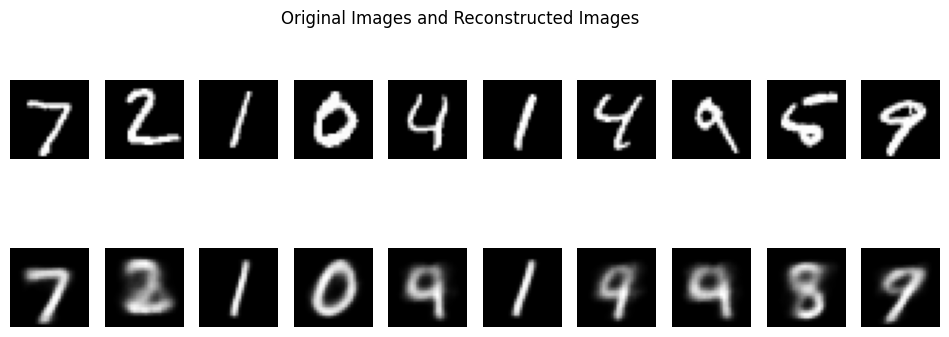

In [ ]:
# Reconstruct sample images
sample_images = x_test[:10]

_, _, latent_vectors = encoder.predict(sample_images)

reconstructed_images = decoder.predict(latent_vectors)

plt.figure(figsize=(12, 4))

for i in range(10):

    # Original images
    plt.subplot(2, 10, i + 1)

    plt.imshow(
        sample_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

    # Reconstructed images
    plt.subplot(2, 10, i + 11)

    plt.imshow(
        reconstructed_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Original Images and Reconstructed Images")

plt.show()


PART 2 : GENERATIVE ADVERSARIAL NETWORK (GAN)

In [ ]:
(x_train_gan, _), (_, _) = tf.keras.datasets.mnist.load_data()

In [ ]:
# Normalize images
x_train_gan = x_train_gan.astype("float32")

x_train_gan = (x_train_gan - 127.5) / 127.5

x_train_gan = x_train_gan.reshape(-1, 28, 28, 1)

batch_size = 128
noise_dim = 100

In [ ]:
# Create TensorFlow dataset
gan_dataset = tf.data.Dataset.from_tensor_slices(x_train_gan)

gan_dataset = gan_dataset.shuffle(60000).batch(batch_size)


In [ ]:
# ---------------- Generator ----------------
# Generates fake images from random noise

def build_generator():

    model = tf.keras.Sequential([

        layers.Dense(
            7 * 7 * 128,
            input_shape=(noise_dim,)
        ),

        layers.LeakyReLU(0.2),

        layers.Reshape((7, 7, 128)),

        layers.Conv2DTranspose(
            64,
            4,
            strides=2,
            padding="same"
        ),

        layers.LeakyReLU(0.2),

        layers.Conv2DTranspose(
            1,
            4,
            strides=2,
            padding="same",
            activation="tanh"
        )
    ])

    return model


In [ ]:
# ---------------- Discriminator ----------------
# Distinguishes real images from fake images

def build_discriminator():

    model = tf.keras.Sequential([

        layers.Conv2D(
            64,
            4,
            strides=2,
            padding="same",
            input_shape=(28, 28, 1)
        ),

        layers.LeakyReLU(0.2),

        layers.Dropout(0.3),

        layers.Conv2D(
            128,
            4,
            strides=2,
            padding="same"
        ),

        layers.LeakyReLU(0.2),

        layers.Dropout(0.3),

        layers.Flatten(),

        layers.Dense(1)
    ])

    return model


In [ ]:
# Create GAN models
generator = build_generator()

discriminator = build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Loss function
loss_function = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

In [ ]:
# Optimizers
generator_optimizer = tf.keras.optimizers.Adam(1e-4)

discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [ ]:
# Generator loss
def generator_loss(fake_output):

    return loss_function(
        tf.ones_like(fake_output),
        fake_output
    )

In [ ]:
# Discriminator loss
def discriminator_loss(real_output, fake_output):

    real_loss = loss_function(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = loss_function(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

In [ ]:
# Training step
@tf.function
def train_gan_step(images):

    # Create random noise
    noise = tf.random.normal(
        [tf.shape(images)[0], noise_dim]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        # Generate fake images
        fake_images = generator(
            noise,
            training=True
        )

        # Get discriminator outputs
        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            fake_images,
            training=True
        )

        # Calculate losses
        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    # Compute gradients
    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update weights
    generator_optimizer.apply_gradients(
        zip(gen_gradients, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

In [ ]:
# Generate fixed noise for visualization
fixed_noise = tf.random.normal([16, noise_dim])

In [ ]:
# Function to display generated images
def show_generated_images(epoch):

    predictions = generator(
        fixed_noise,
        training=False
    )

    plt.figure(figsize=(5, 5))

    for i in range(16):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            predictions[i, :, :, 0] * 127.5 + 127.5,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(f"GAN Generated Images - Epoch {epoch}")

    plt.show()

Epoch 1 | Generator Loss: 2.1917 | Discriminator Loss: 0.2163
Epoch 2 | Generator Loss: 2.8910 | Discriminator Loss: 0.3796
Epoch 3 | Generator Loss: 1.9727 | Discriminator Loss: 0.7593
Epoch 4 | Generator Loss: 1.8670 | Discriminator Loss: 0.7495
Epoch 5 | Generator Loss: 2.1760 | Discriminator Loss: 0.5088


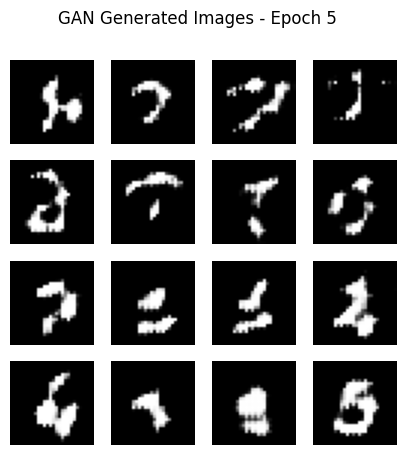

Epoch 6 | Generator Loss: 1.3127 | Discriminator Loss: 1.0505
Epoch 7 | Generator Loss: 1.4951 | Discriminator Loss: 0.8991
Epoch 8 | Generator Loss: 1.8759 | Discriminator Loss: 0.6340
Epoch 9 | Generator Loss: 1.4546 | Discriminator Loss: 0.8616
Epoch 10 | Generator Loss: 1.6809 | Discriminator Loss: 0.7743


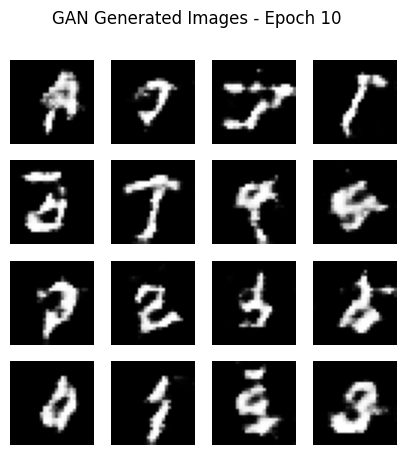

In [ ]:
# Train GAN
epochs = 10

for epoch in range(1, epochs + 1):

    for image_batch in gan_dataset:

        g_loss, d_loss = train_gan_step(image_batch)

    print(
        f"Epoch {epoch} | "
        f"Generator Loss: {g_loss:.4f} | "
        f"Discriminator Loss: {d_loss:.4f}"
    )

    # Show generated images
    if epoch % 5 == 0:

        show_generated_images(epoch)

# PART 3 : GRAPH CONVOLUTIONAL NETWORK (GCN)

In [ ]:
# Load Cora citation dataset
dataset = Planetoid(
    root="/tmp/Cora",
    name="Cora"
)

data = dataset[0]

print("Nodes:", data.num_nodes)
print("Edges:", data.num_edges)
print("Features:", dataset.num_node_features)
print("Classes:", dataset.num_classes)


Nodes: 2708
Edges: 10556
Features: 1433
Classes: 7


Processing...
Done!


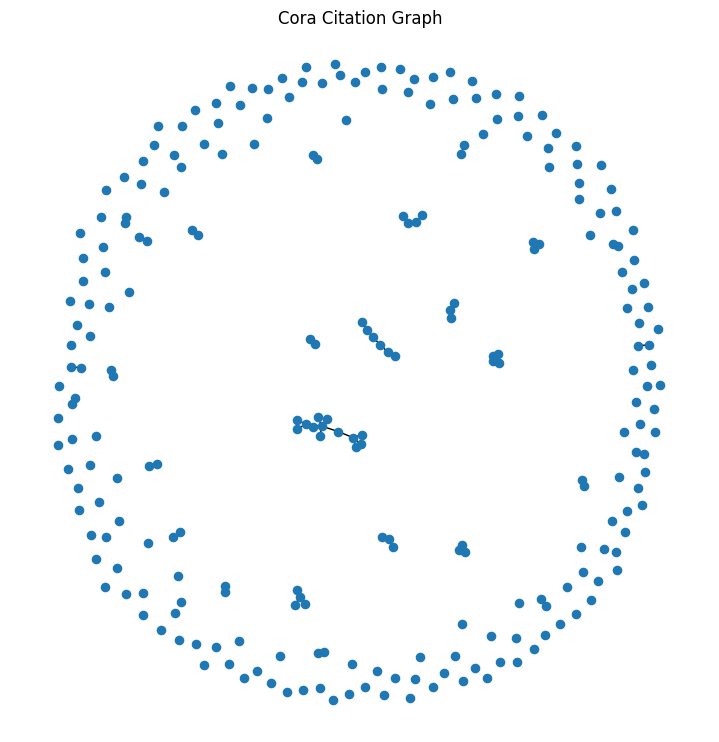

In [ ]:
# Visualize small graph
graph = to_networkx(
    data,
    to_undirected=True
)

plt.figure(figsize=(7, 7))

small_graph = graph.subgraph(list(range(250)))

nx.draw(
    small_graph,
    node_size=35,
    with_labels=False
)

plt.title("Cora Citation Graph")

plt.show()

In [ ]:
# GCN model
class GCN(torch.nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GCNConv(
            dataset.num_node_features,
            32
        )

        self.conv2 = GCNConv(
            32,
            dataset.num_classes
        )

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        # First graph convolution layer
        x = self.conv1(x, edge_index)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.5,
            training=self.training
        )

        # Second graph convolution layer
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)


In [ ]:
# Set device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

In [ ]:
# Move model and data to GPU
gcn_model = GCN().to(device)

data = data.to(device)

In [ ]:
# Optimizer
optimizer = torch.optim.Adam(
    gcn_model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

In [ ]:
# Training function
def train_gcn():

    gcn_model.train()

    optimizer.zero_grad()

    output = gcn_model(data)

    loss = F.nll_loss(
        output[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

    return loss.item()

In [ ]:
# Evaluation function
def test_gcn():

    gcn_model.eval()

    output = gcn_model(data)

    prediction = output.argmax(dim=1)

    accuracies = []

    for mask in [
        data.train_mask,
        data.val_mask,
        data.test_mask
    ]:

        correct = prediction[mask].eq(
            data.y[mask]
        ).sum().item()

        accuracy = correct / mask.sum().item()

        accuracies.append(accuracy)

    return accuracies


In [ ]:
# Train GCN
for epoch in range(1, 201):

    loss = train_gcn()

    train_acc, val_acc, test_acc = test_gcn()

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch} | "
            f"Loss: {loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Test Acc: {test_acc:.4f}"
        )

Epoch 20 | Loss: 0.0683 | Train Acc: 1.0000 | Val Acc: 0.7700 | Test Acc: 0.7940
Epoch 40 | Loss: 0.0139 | Train Acc: 1.0000 | Val Acc: 0.7840 | Test Acc: 0.8060
Epoch 60 | Loss: 0.0207 | Train Acc: 1.0000 | Val Acc: 0.7640 | Test Acc: 0.8090
Epoch 80 | Loss: 0.0183 | Train Acc: 1.0000 | Val Acc: 0.7740 | Test Acc: 0.8120
Epoch 100 | Loss: 0.0169 | Train Acc: 1.0000 | Val Acc: 0.7740 | Test Acc: 0.8050
Epoch 120 | Loss: 0.0171 | Train Acc: 1.0000 | Val Acc: 0.7780 | Test Acc: 0.8170
Epoch 140 | Loss: 0.0189 | Train Acc: 1.0000 | Val Acc: 0.7780 | Test Acc: 0.8170
Epoch 160 | Loss: 0.0193 | Train Acc: 1.0000 | Val Acc: 0.7720 | Test Acc: 0.8010
Epoch 180 | Loss: 0.0124 | Train Acc: 1.0000 | Val Acc: 0.7680 | Test Acc: 0.8040
Epoch 200 | Loss: 0.0145 | Train Acc: 1.0000 | Val Acc: 0.7700 | Test Acc: 0.8120


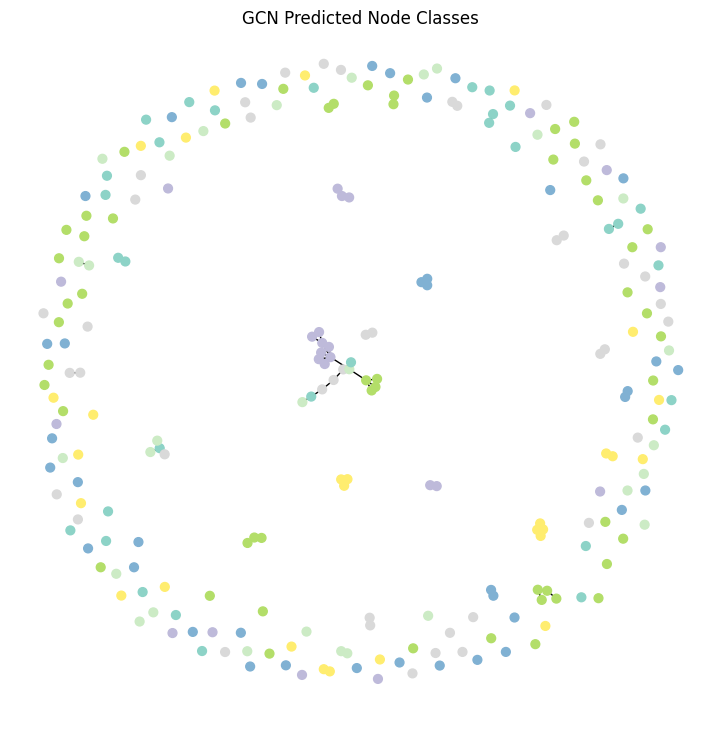

In [ ]:
# Visualize predicted classes
gcn_model.eval()

output = gcn_model(data)

predicted_classes = output.argmax(dim=1).cpu()

graph_cpu = to_networkx(
    data.cpu(),
    to_undirected=True
)

sub_nodes = list(range(250))

sub_graph = graph_cpu.subgraph(sub_nodes)

node_colors = [
    predicted_classes[node].item()
    for node in sub_nodes
]

plt.figure(figsize=(7, 7))

nx.draw(
    sub_graph,
    node_color=node_colors,
    cmap=plt.cm.Set3,
    node_size=40,
    with_labels=False
)

plt.title("GCN Predicted Node Classes")

plt.show()